## 1. Load Dataset

In [1]:
import pandas as pd 

data = pd.read_csv("C:/Coding SDT/Project/stock-analysis/data/processed/feature_matrix.csv")
data.head()

,Date,Close,High,Low,Open,Volume,OBV,ADI,VWAP,RSI_14,...,Return_2d,Return_3d,Return_5d,Day_of_Week,IHSG_Return,Next_Day_Open,Next_Day_Close,Next_Day_Return,Target,Ticker
0,2020-03-11,4844.544922,4952.201476,4794.857282,4927.357656,93204500,-180339000,-9.519408e+08,5170.420196,30.835031,...,0.011236,-0.056452,-0.091615,2,-0.01278,4637.513770,4604.388672,-0.007143,0,BBCA.JK
1,2020-03-11,2878.674561,3049.838994,2800.872545,3026.498389,6061500,-25603400,-7.651988e+07,3099.339850,36.789749,...,-0.021164,-0.095355,-0.065657,2,-0.01278,2878.674695,2707.510254,-0.059459,0,BTPS.JK
2,2020-03-11,5378.917480,5489.443182,5213.128928,5231.549878,19638900,-11138500,-7.310563e+07,5278.259060,45.811856,...,0.039146,-0.020134,-0.016835,2,-0.01278,5323.654785,5323.654785,0.000000,0,UNVR.JK
3,2020-03-11,520.000000,520.000000,520.000000,520.000000,0,-37100,3.586000e+04,509.759152,49.386678,...,0.000000,0.000000,0.000000,2,-0.01278,520.000000,520.000000,0.000000,0,BSIM.JK
4,2020-03-11,445.379608,452.421195,434.817249,443.619201,12107327,130560344,4.112048e+07,436.082561,54.553024,...,0.049792,0.020161,0.003968,2,-0.01278,445.379642,429.536102,-0.035573,0,SIDO.JK


## 2. Check Information Dataset

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140052 entries, 0 to 140051
Data columns (total 30 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date             140052 non-null  object 
 1   Close            140052 non-null  float64
 2   High             140052 non-null  float64
 3   Low              140052 non-null  float64
 4   Open             140052 non-null  float64
 5   Volume           140052 non-null  int64  
 6   OBV              140052 non-null  int64  
 7   ADI              140052 non-null  float64
 8   VWAP             140052 non-null  float64
 9   RSI_14           140052 non-null  float64
 10  MACD             140052 non-null  float64
 11  MACD_Signal      140052 non-null  float64
 12  MACD_Diff        140052 non-null  float64
 13  BB_High          140052 non-null  float64
 14  BB_Low           140052 non-null  float64
 15  BB_Mid           140052 non-null  float64
 16  ATR_14           140052 non-null  floa

## 3. Check Null Value

In [3]:
data.isnull().sum()

Date                0
Close               0
High                0
Low                 0
Open                0
Volume              0
OBV                 0
ADI                 0
VWAP                0
RSI_14              0
MACD                0
MACD_Signal         0
MACD_Diff           0
BB_High             0
BB_Low              0
BB_Mid              0
ATR_14              0
SMA_20              0
SMA_50              0
Return_1d           0
Return_2d           0
Return_3d           0
Return_5d           0
Day_of_Week         0
IHSG_Return         0
Next_Day_Open      96
Next_Day_Close     96
Next_Day_Return    96
Target              0
Ticker              0
dtype: int64

## 4. Viewing the Histogram

In [4]:
print(f"Shape: {data.shape}")

Shape: (140052, 30)


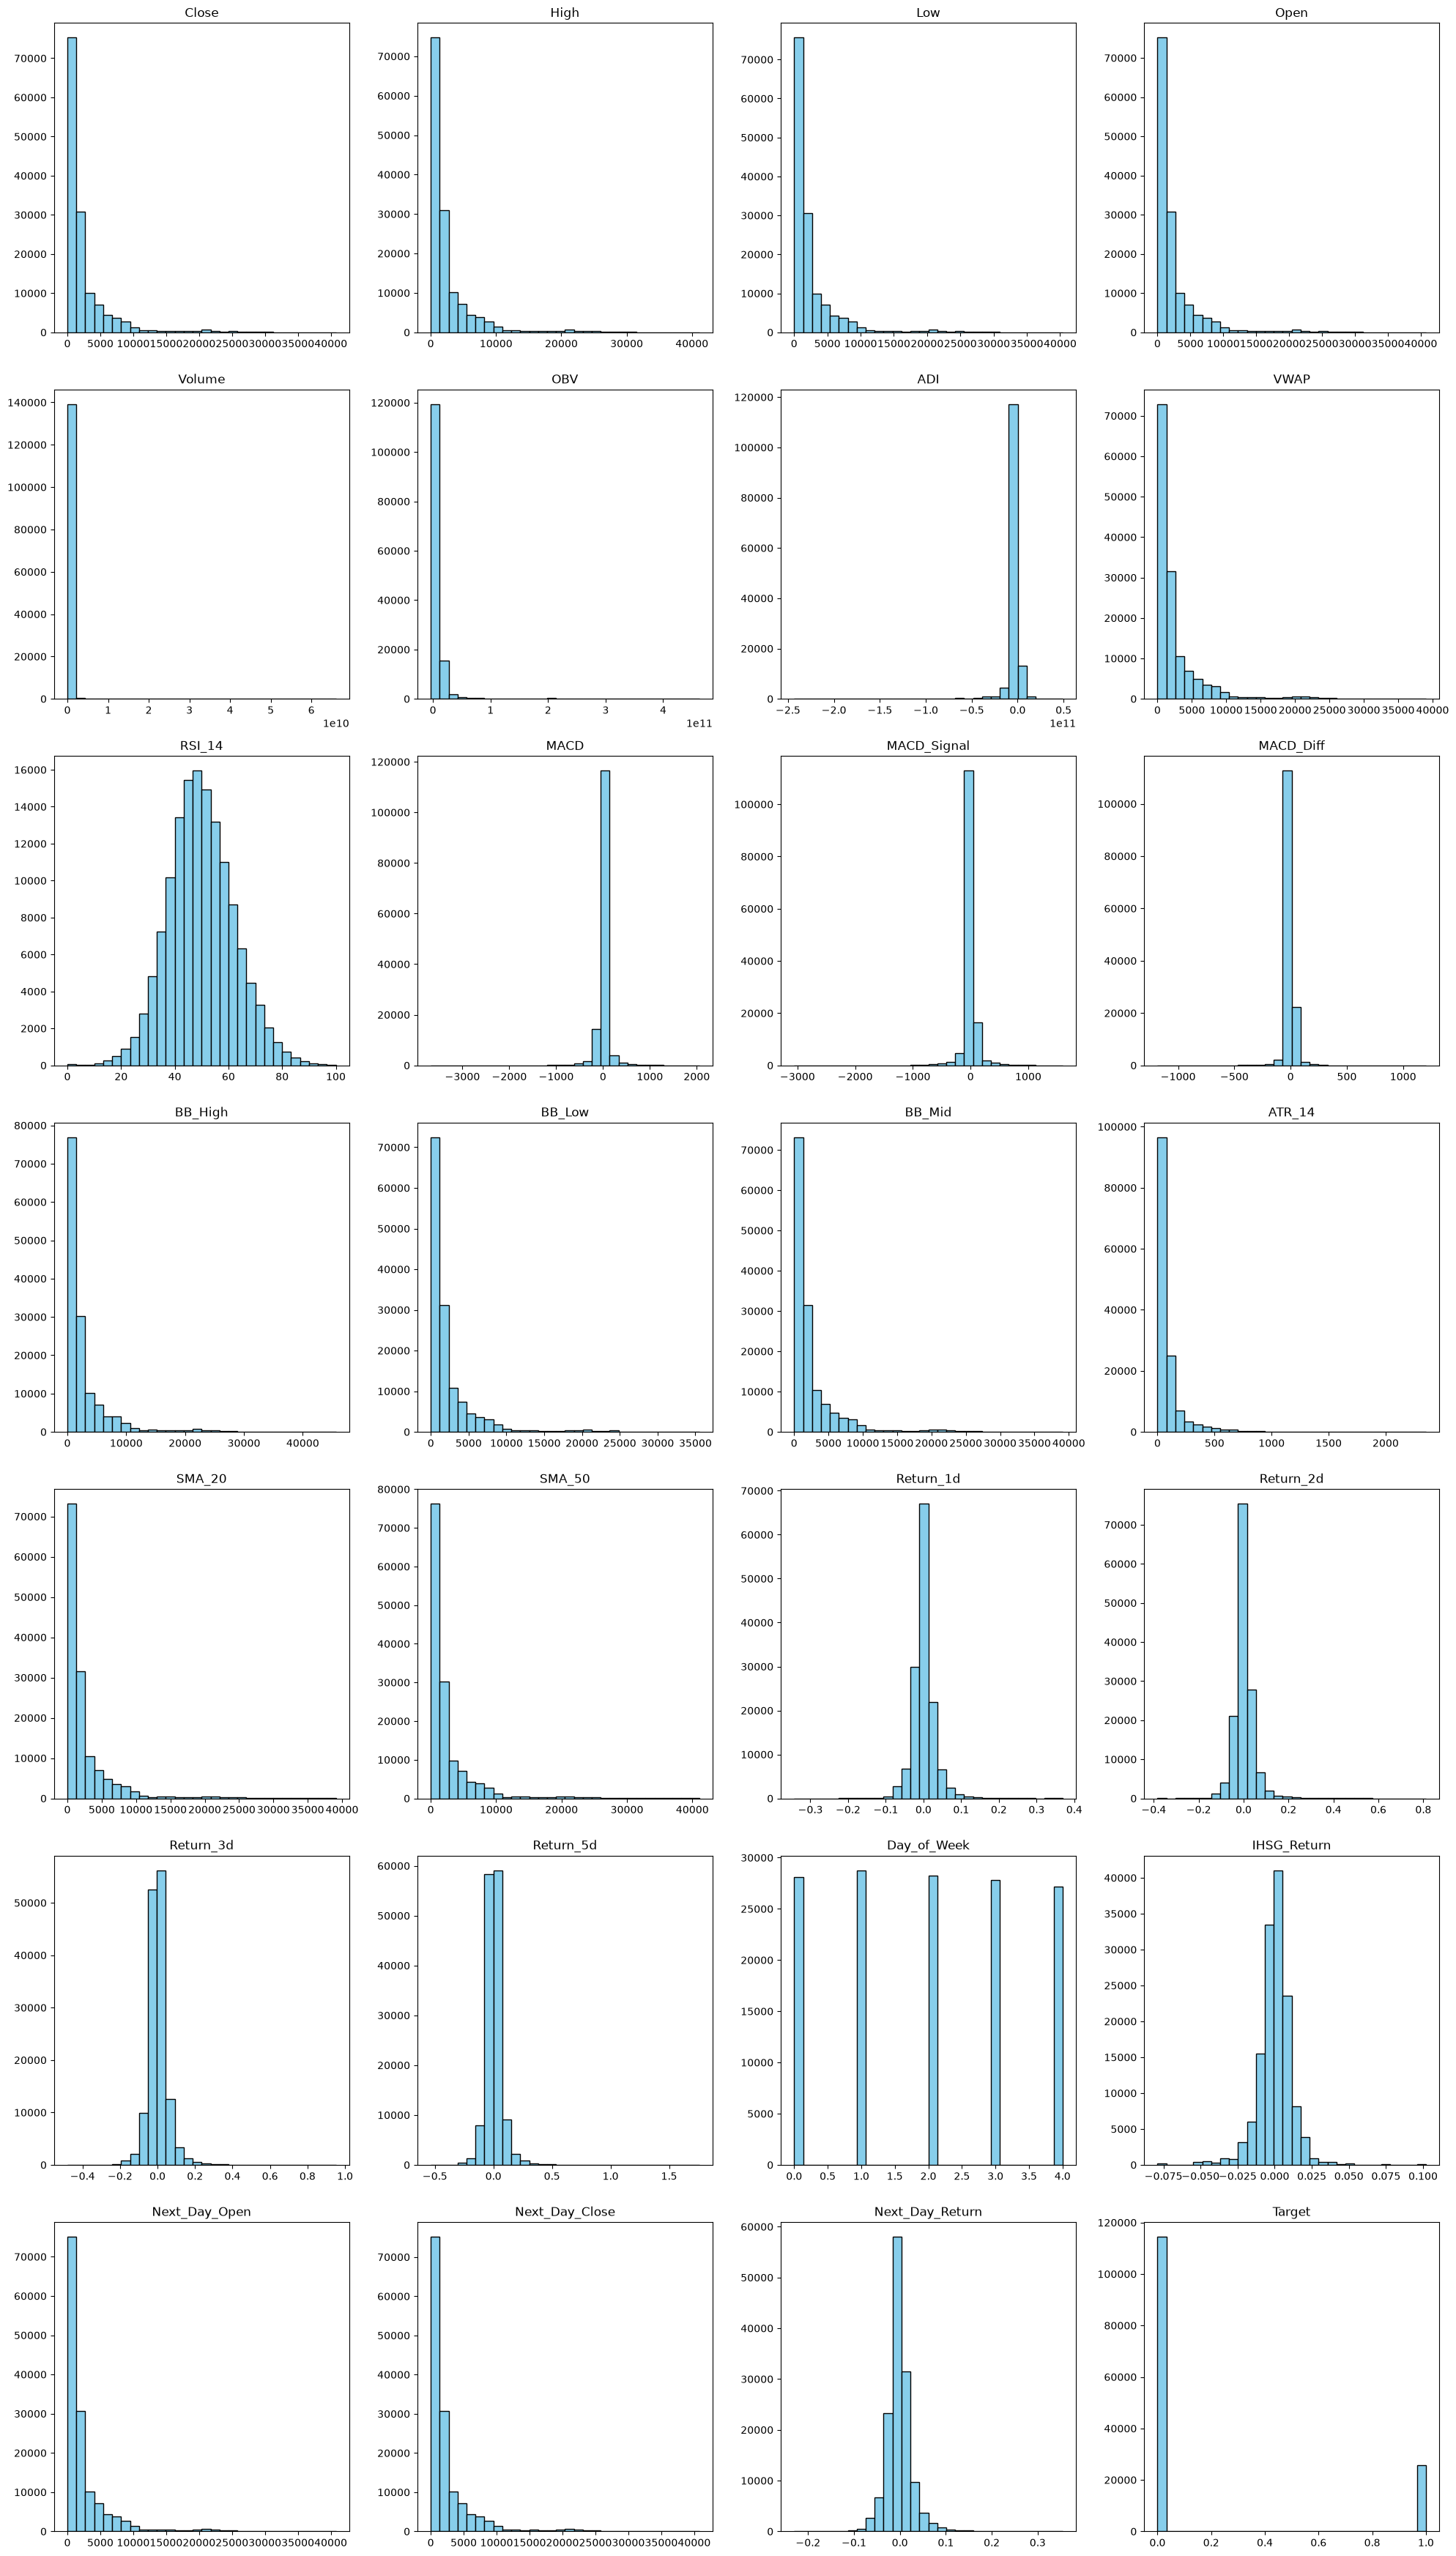

In [5]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# data = pd.read_csv('../data/processed/feature_matrix.csv')
num_cols = data.select_dtypes(include='number').columns

if len(num_cols) == 0:
    print("No numerical columns found. Please check your 'data' variable.")
else:
    n_cols = 4
    n_rows = math.ceil(len(num_cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        # FIX: Replace 'inf' and '-inf' with NaN, then drop all NaNs
        clean_data = data[col].replace([np.inf, -np.inf], np.nan).dropna()
        
        # Only plot if there is still data left after cleaning
        if not clean_data.empty:
            axes[i].hist(clean_data, bins=30, color='skyblue', edgecolor='black')
            axes[i].set_title(col)
        else:
            axes[i].set_title(f"{col} (Empty/All Invalid)")

    for j in range(len(num_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

## 5. Check Outlier 

C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_8176\3872739331.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(clean_data, vert=False)
C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_8176\3872739331.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(clean_data, vert=False)
C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_8176\3872739331.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(clean_data, vert=False)
C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_8176\3872739331.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3

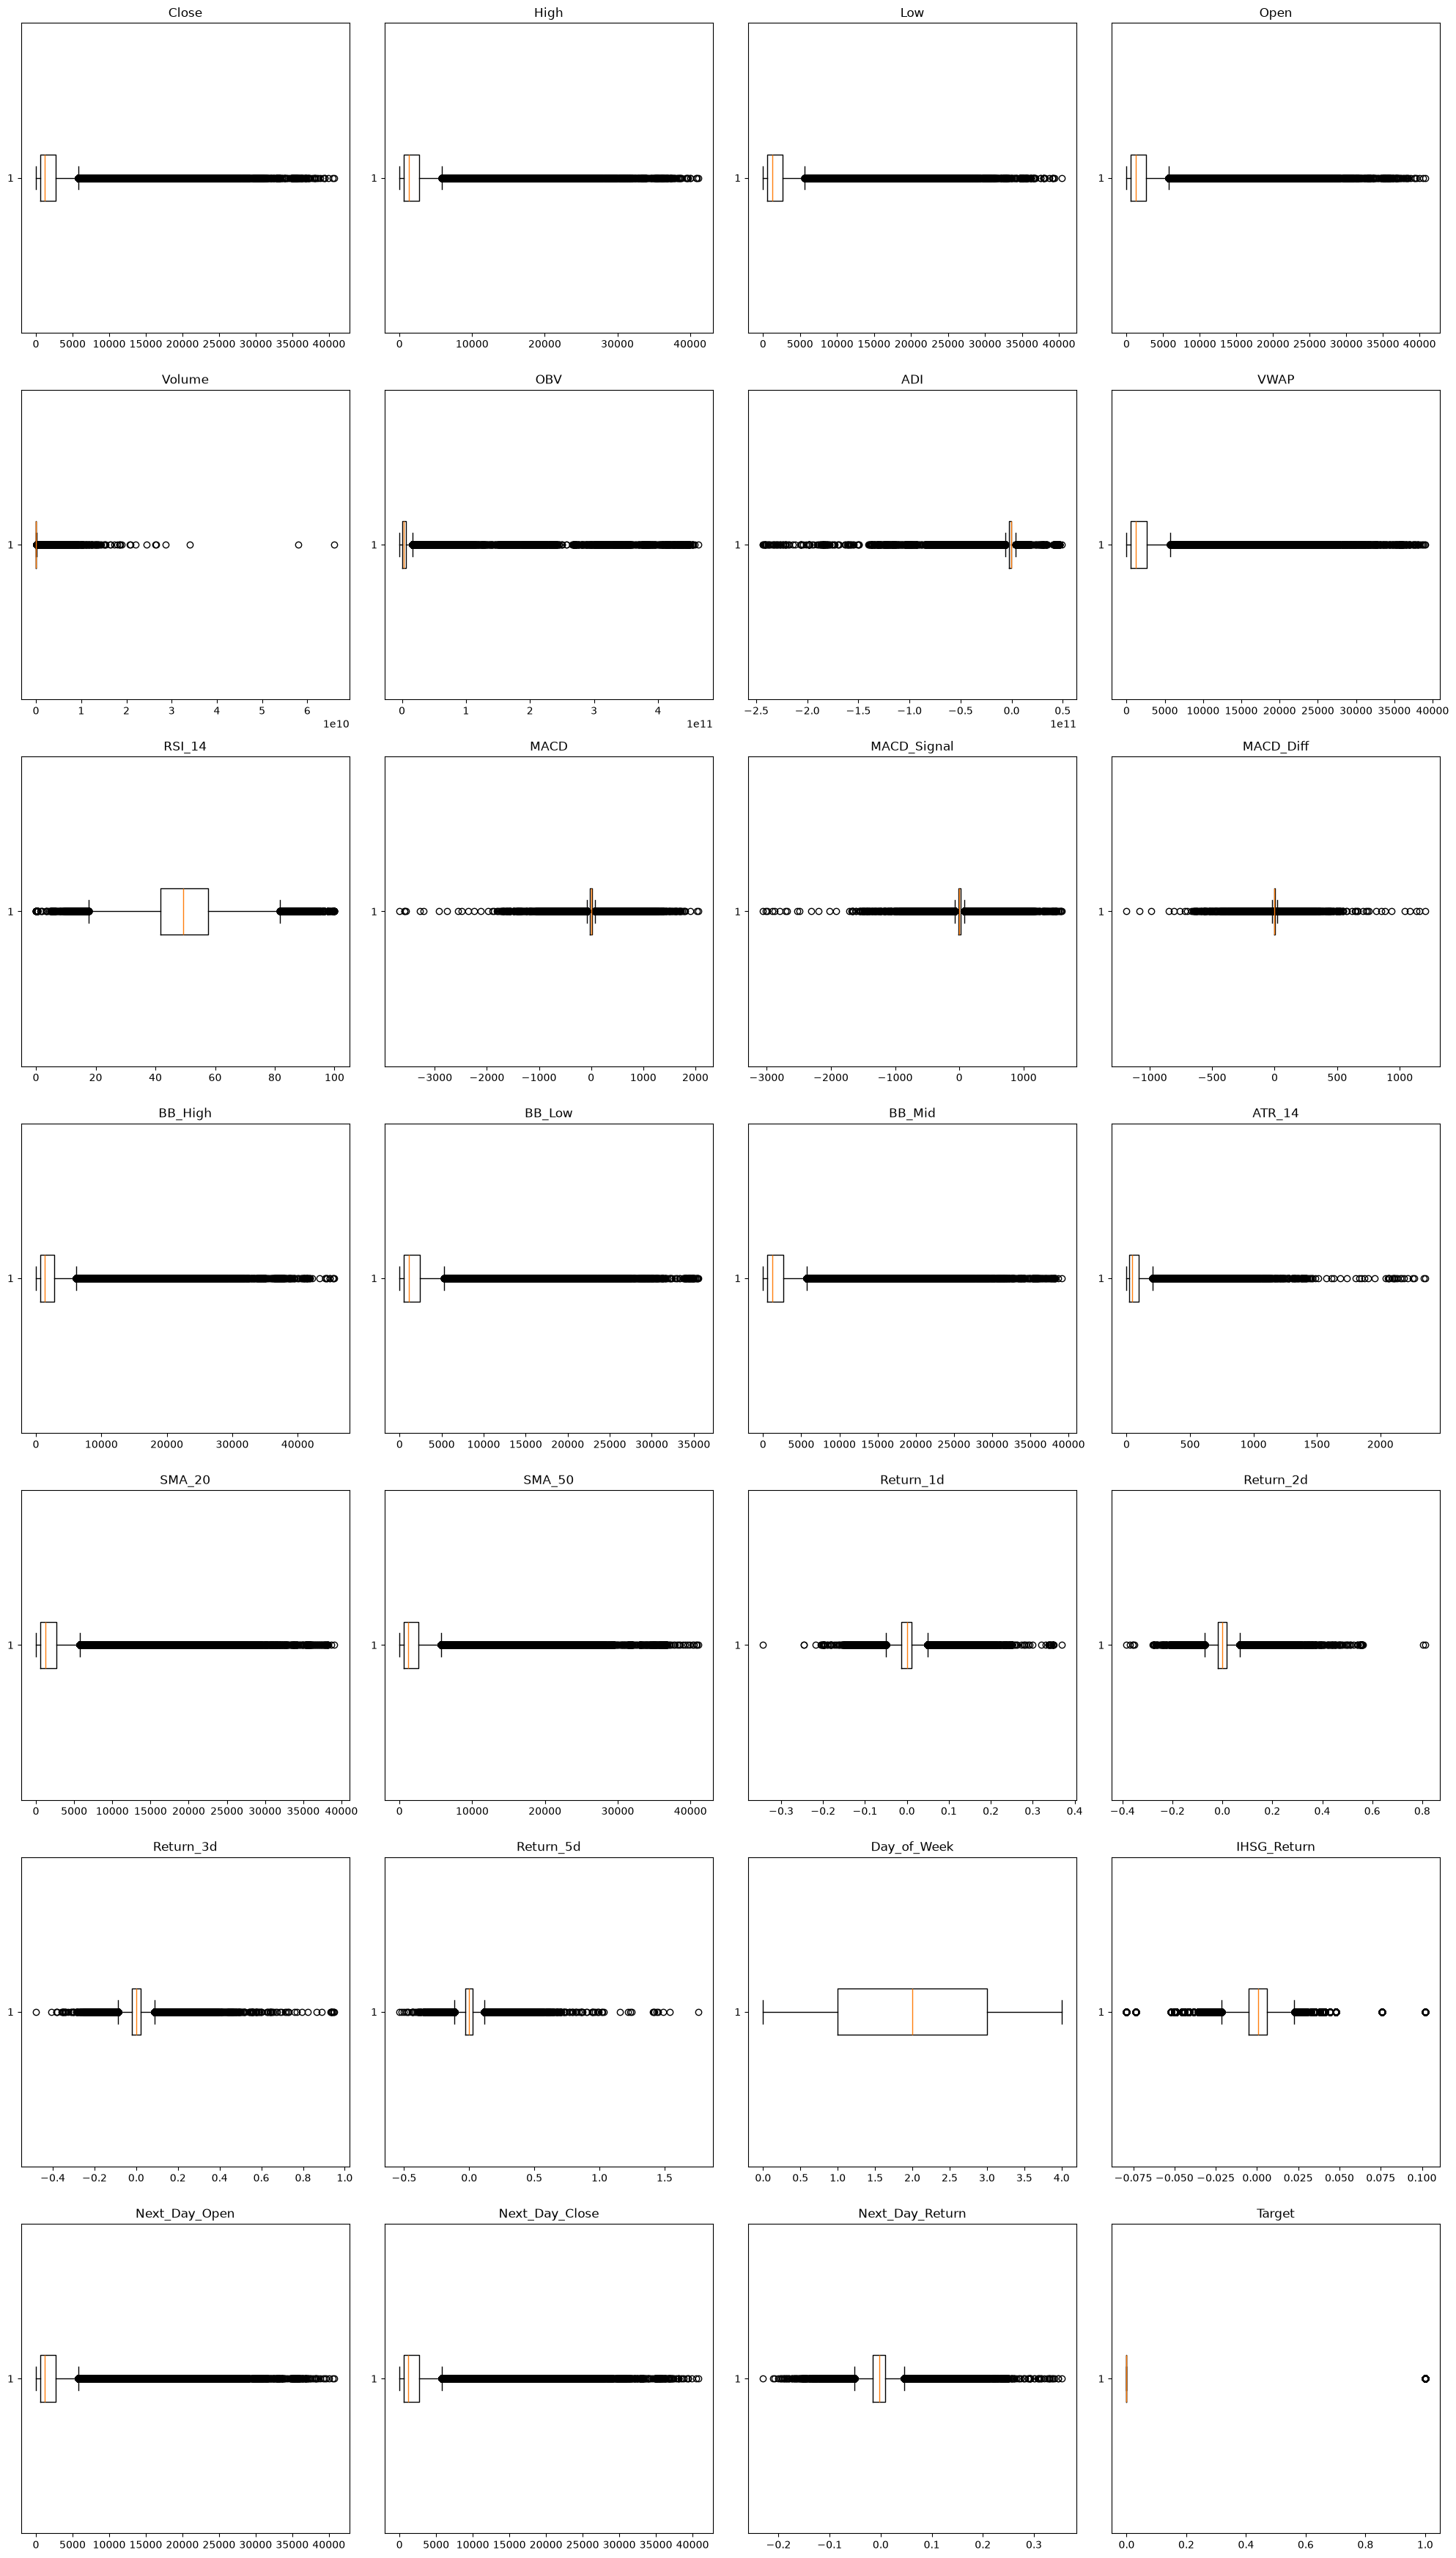

In [6]:
import math
import numpy as np
import matplotlib.pyplot as plt

num_cols = data.select_dtypes(include='number').columns

if len(num_cols) == 0:
    print("No numerical columns found. Please check your 'data' variable.")
else:
    n_cols = 4
    n_rows = math.ceil(len(num_cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        # Clean the data: replace inf/-inf with NaN, then drop NaNs
        clean_data = data[col].replace([np.inf, -np.inf], np.nan).dropna()
        
        # Only draw the boxplot if there is data left to plot
        if not clean_data.empty:
            # Using vert=False is optional, but often makes boxplots easier to read!
            axes[i].boxplot(clean_data, vert=False) 
            axes[i].set_title(col)
        else:
            axes[i].set_title(f"{col} (Empty/Invalid)")

    # Safely remove any extra empty subplots 
    for j in range(len(num_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


## 6. Check Imbalance from Dataset

C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_8176\1763361843.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


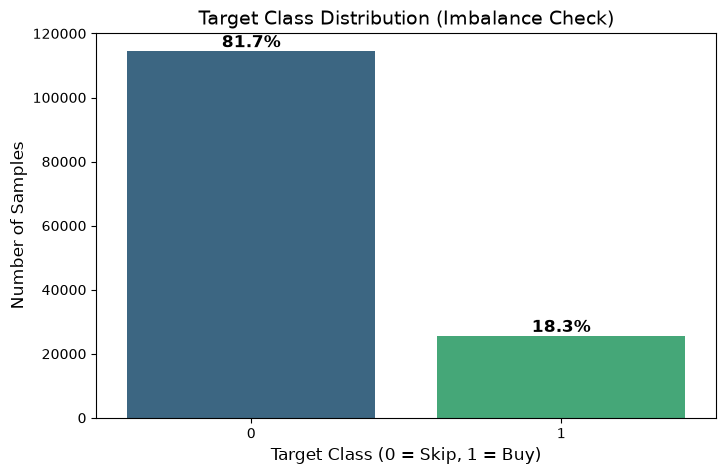

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your target column is named 'Target'
# Adjust 'Target' or 'dataset' to match your actual variable names
class_counts = data['Target'].value_counts()
class_percentages = data['Target'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')

# Add percentage labels on top of the bars
for i, p in enumerate(ax.patches):
    percentage = f'{class_percentages.iloc[i]:.1f}%'
    ax.annotate(percentage, 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Target Class Distribution (Imbalance Check)', fontsize=14)
plt.xlabel('Target Class (0 = Skip, 1 = Buy)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.show()

## 7. Correlation Heatmap

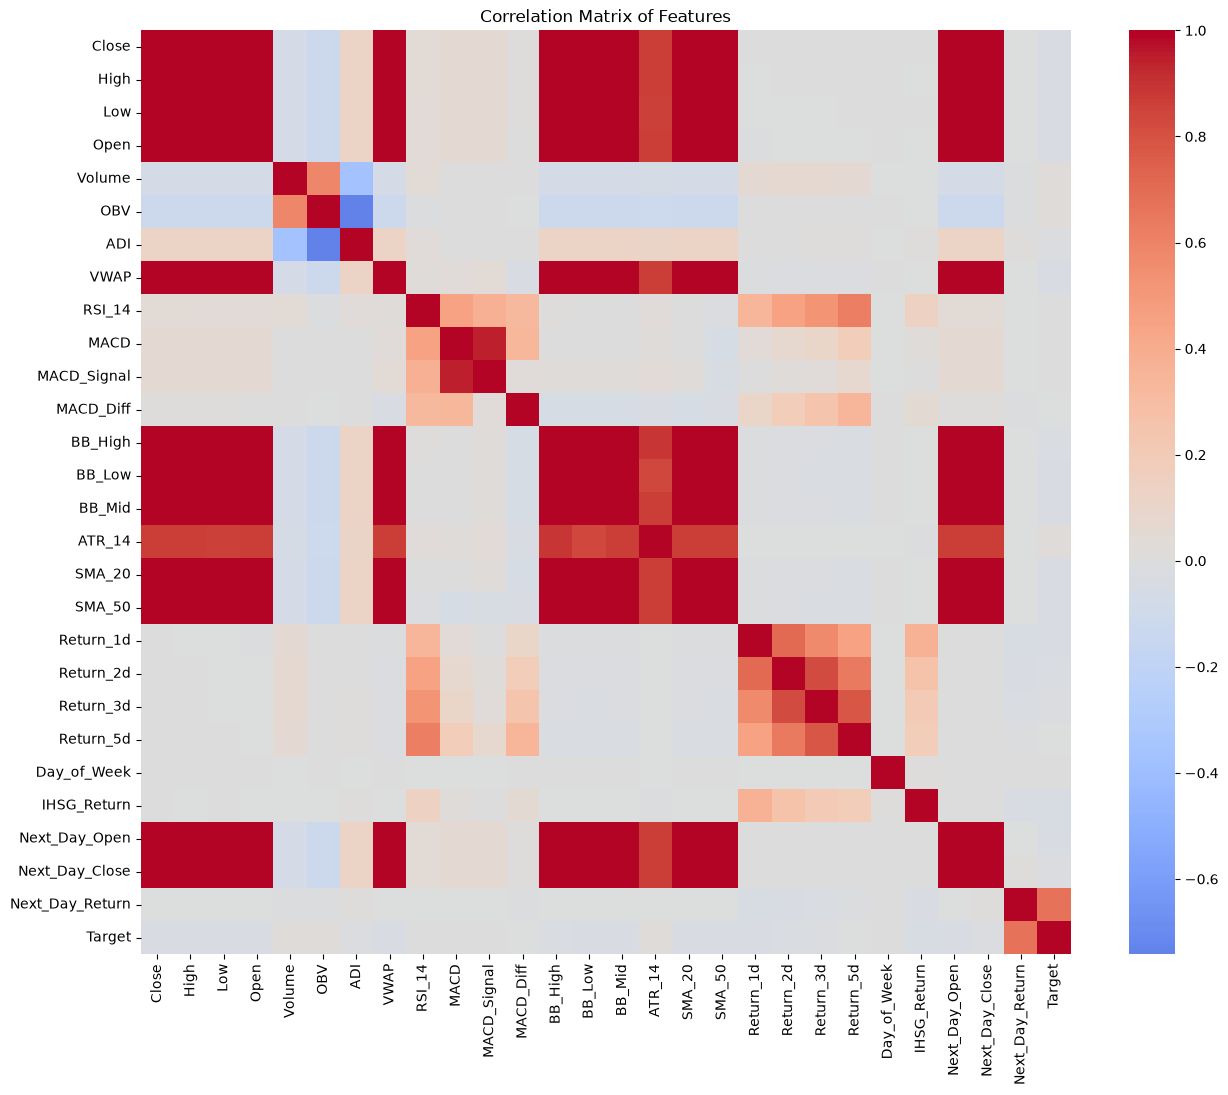

In [8]:
import seaborn as sns

plt.figure(figsize=(15, 12))
# Hitung korelasi hanya pada fitur numerik
corr = data.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Features')
plt.show()

## 8. Feature vs Target Analysis

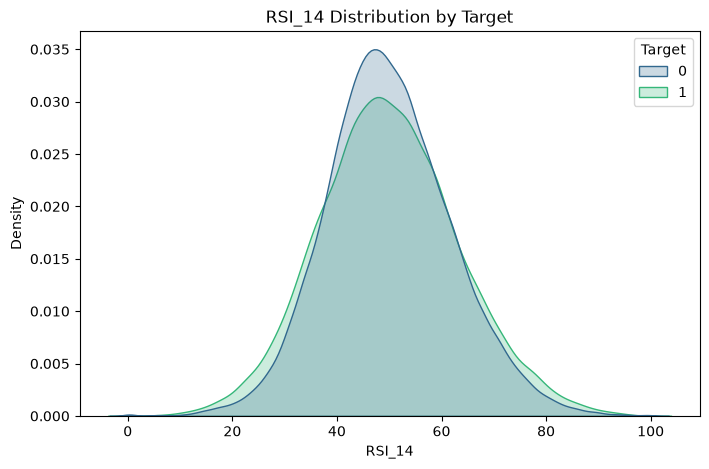

In [9]:
# Contoh membandingkan nilai RSI_14 antara saham yang bakal naik vs turun
plt.figure(figsize=(8, 5))
sns.kdeplot(data=data, x='RSI_14', hue='Target', fill=True, common_norm=False, palette='viridis')
plt.title('RSI_14 Distribution by Target')
plt.show()

## 9. Data Leakage Check

In [10]:
# Kolom yang tidak boleh ikut di-training
leakage_cols = ['Next_Day_Open', 'Next_Day_Close', 'Next_Day_Return']

# Pastikan mereka dihapus sebelum masuk tahap Modelling
model_data = data.drop(columns=leakage_cols)